In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from scipy.spatial.distance import cdist

## Weekly Data Management Pipeline

Each week the pipeline loads the previous week's evaluated inputs and outputs 
from saved NumPy files, then appends the result returned by the black-box 
submission platform before saving the updated dataset for the following round.

**Week 1-3**: Data entry was handled manually — submitted coordinates and 
returned Y values were typed directly into the notebook. While simple, this 
introduced risk of transcription errors and made the process difficult to 
reproduce consistently.

**Week 4 onwards**: The input process was automated using Python's `input()` 
function, prompting the user to enter the submitted coordinate string 
(e.g. `0.419100-0.366397-0.472000`) and the returned Y value each week. 
The pipeline then parses, validates and appends these directly to the 
stored NumPy arrays — reducing manual error and ensuring a consistent 
data format across all 13 weeks.

**Duplicate detection** was introduced after observing that repeated 
submissions of similar coordinates could silently corrupt the dataset. 
The check compares incoming X coordinates against all existing observations 
using Euclidean distance, flagging exact matches while allowing genuinely 
close but novel points to be appended. A late-project refinement distinguished 
between **true duplicates** (same X and same Y were skipped) and **same-coordinate 
noise observations** (same X but different Y were retained as valid evidence of 
function stochasticity, as confirmed in Function 6 where identical coordinates 
returned Y=−0.3056 in week 11 and Y=−0.1425 in week 13).

In [10]:
current_week = 14   # CHANGE THIS EACH WEEK

# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_2\initial_inputs.npy")
    Y = np.load(r"function_2\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_2/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_2/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    if not exists:

        X = np.vstack((X, x_last))
        Y = np.append(Y, y_last)

        print("Added last result.")

    else:

        print("Duplicate detected — skipped.")



Loaded dataset:
Shape: (28, 2)
Best Y so far: 0.7392388080406241

Enter last week's result


Enter last submitted X (format x1-x2):  0.858904-0.385833
Enter returned Y value:  0.7251680408777501


Added last result.


Saving the Data Files.
Appended data is saved to a new file each week.

This ensures a copy of the exact results per week are maintained for the records

In [11]:
# =====================================================
# SAVE UPDATED DATA
# =====================================================

np.save(
    f"function_2/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_2/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_2/w{current_week}_inputs.npy"
)

print(
    f"function_2/w{current_week}_outputs.npy"
)


Saved files:
function_2/w14_inputs.npy
function_2/w14_outputs.npy


In [3]:
# VALIDATE THE LATEST FILE!
X = np.load("function_2/w11_inputs.npy")

print("Shape:", X.shape)
print("Last row:", X[-1])

Shape: (26, 2)
Last row: [0.854734 0.390124]


Analysis performed on the dataset each week to display the best points so far. 
This aids the analysis and directs strategy for the coming week.

In [14]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_2/w14_inputs.npy")
Y = np.load("function_2/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.6f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:  {np.max(Y):.6f}")
print(f"Mean Y:  {np.mean(Y):.6f}")
print(f"Std Y:   {np.std(Y):.6f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nPoints ranked by distance to best:")
for i in sorted_by_dist:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | Y={Y[i]:.6f} | X={vals}")

All points ranked best to worst:
  Y=0.739239 | X=0.856640-0.387807
  Y=0.732982 | X=0.856029-0.384868
  Y=0.725168 | X=0.858904-0.385833
  Y=0.703129 | X=0.853749-0.387004
  Y=0.687702 | X=0.857721-0.356525
  Y=0.668964 | X=0.877610-0.388215
  Y=0.622886 | X=0.857006-0.375492
  Y=0.617439 | X=0.857957-0.390504
  Y=0.563782 | X=0.854734-0.390124
  Y=0.555048 | X=0.855559-0.400212
  Y=0.438508 | X=0.671995-0.926578
  Y=-0.000000 | X=0.555082-0.058018
  Y=-0.026241 | X=0.416484-0.379587
  Y=-0.034835 | X=0.492581-0.611593
  Y=-0.036378 | X=0.600097-0.725136
  Y=-0.038996 | X=0.799217-0.964963
  Y=-0.046947 | X=0.220549-0.297825
  Y=-0.048008 | X=0.134622-0.219917
  Y=-0.056758 | X=0.965995-0.861120
  Y=-0.087963 | X=0.242114-0.644074
  Y=-0.094190 | X=0.170477-0.697032
  Y=-0.105965 | X=0.666014-0.671985
  Y=-0.110621 | X=0.345523-0.941360
  Y=-0.111415 | X=0.534906-0.398501
  Y=-0.112122 | X=0.171525-0.343917
  Y=-0.113869 | X=0.645503-0.397143
  Y=-0.118048 | X=0.046809-0.231360
  Y=-0

## Function 2 — Noisy Log-Likelihood Optimisation (2D)

**Objective**: Maximise the output of a 2-dimensional noisy 
function. All meaningful results cluster in a narrow confirmed 
region — the challenge is identifying that region early and 
then managing the inherent noise to extract the best possible 
result from repeated sampling.

---

### What Makes Function 2 Different — Observation Noise

Function 2 is explicitly **noisy** — querying the same input 
coordinates on different weeks does not return the same output. 


---

### Kernel Choice — Matérn over RBF

The GP used a **Matérn kernel (ν=2.5)** rather than the standard 
RBF kernel:



**Why Matérn rather than RBF?**

The RBF kernel assumes the function is **infinitely smooth** — 
every point on the landscape connects perfectly smoothly to 
every other point. For a noisy log-likelihood function this 
assumption is unrealistic. The Matérn kernel with ν=2.5 
assumes the function is smooth but **allows for more local 
variation**.


The fitted kernel length scales provide a useful weekly diagnostic:

| Dimension | Typical length scale | Interpretation |
|-----------|---------------------|----------------|
| x1 | 0.35-0.38 | Moderate sensitivity — x1 influences output meaningfully |
| x2 | 0.87-0.98 | Lower sensitivity — x2 varies more smoothly |

Both dimensions remained well within bounds throughout the project duration
unlike several other functions where dimensions hit the upper 
length scale bound and were effectively ignored by the GP.

---

### Acquisition Functions — The Evolution from EI to Proximity

Three acquisition approaches were used across the project, 
each reflecting a different phase of understanding:

---

#### Phase 1 (Weeks 1-6): Expected Improvement (EI)

EI was appropriate in the early weeks when the peak location 
was still uncertain. As observations accumulated and the peak 
confirmed around [0.8566, 0.3878], EI became progressively 
less useful as it kept seeking high-uncertainty boundary corners 
rather than the confirmed good region, because the boundary 
of the clipped search space always has higher uncertainty 
than a densely sampled interior.

---

#### Phase 2 (Weeks 7-13): Proximity Search

Once the peak was confirmed, **proximity search** replaced EI 
as the primary selection criterion:

```python
dists_to_peak = cdist(X_novel, [confirmed_peak])
x_submit_prox = X_novel[np.argmin(dists_to_peak)]
```

This is deliberately model-free — it ignores the GP's 
predictions entirely and simply finds the closest unqueried 
point to the confirmed peak coordinates [0.8566, 0.3878].

**Why proximity over EI for a noisy function?**

With GP LOO RMSE of approximately 0.177-0.187 on a Y range 
of roughly 1.1, the GP's predictions carry uncertainty of 
approximately **16-17% of the total Y range**. At this level 
of uncertainty, EI was struggling to distinguish between 
candidates within the confirmed peak neighbourhood, the 
prediction error is larger than the differences between 
nearby candidates.

Proximity search acknowledges this honestly: when the surrogate 
cannot reliably distinguish between nearby candidates, submit 
the one closest to the empirically confirmed best location.

---

#### Phase 3 (Weeks 11-13): LOO-Based EI Override

A refinement was added in week 11 to give EI a genuine 
opportunity to override proximity when the GP was 
sufficiently confident:

```python
# EI wins only if it predicts meaningfully higher
# threshold = half a LOO error unit
ei_threshold = gp_rmse * 0.5
if pred_ei > pred_prox + ei_threshold and dist_ei <= 0.015:
    x_final      = x_submit_ei
    chosen_model = "EI (GP trusted — LOO-based threshold)"
```

In practice EI never met this threshold — it consistently 
suggested boundary corners at dist≈0.022 with predictions 
within noise range of proximity's suggestion. This confirmed 
that proximity was the correct long-term strategy for F2 
rather than a compromise — the GP's EI acquisition function 
is structurally biased toward boundaries in a tightly clipped 
search space, regardless of where the true peak lies.

---




### Final Result

| Metric | Value |
|--------|-------|
| Best Y achieved | 0.7392 |
| Week achieved | Week 4 |
| Method | GP EI near confirmed peak |
| Confirmed peak | [0.8566, 0.3878] |
| WhiteKernel noise estimate | σ²≈0.037-0.042 |
| LOO RMSE at finish | 0.177 |

The best result achieved in week 4 was never beaten despite 
nine further attempts in the same neighbourhood.  Potentially a
consequence of the function's noise level rather than any 
limitation of the search strategy. One possible conclusion is 
that **the week 4 result may itself have benefited from a 
favourable noise draw**, and the true underlying value at 
[0.8566, 0.3878] is likely somewhere in the 0.65-0.73 range 
based on the distribution of observed results.

Fitted kernel:
0.762**2 * Matern(length_scale=[0.396, 1.04], nu=2.5) + WhiteKernel(noise_level=0.0349)
  x1 length scale: 0.3961
  x2 length scale: 1.0379

Best real point:    [0.85664  0.387807]
Confirmed peak:     [0.8566 0.3878]
Best real Y:        0.739239

GP LOO RMSE: 0.177994

Candidate x1 range: 0.8400 — 0.8700
Candidate x2 range: 0.3700 — 0.4050
Novel candidates:   156289

ACQUISITION COMPARISON — Function 2

--- EI ---
  Suggestion:         0.870000-0.370000
  x1=0.870000 | x2=0.370000
  GP predicted Y:     0.6889
  Distance from peak: 0.022280
  x1 vs peak: +0.013400
  x2 vs peak: -0.017800

--- Proximity ---
  Suggestion:         0.860259-0.388559
  x1=0.860259 | x2=0.388559
  GP predicted Y:     0.6624
  Distance from peak: 0.003737
  x1 vs peak: +0.003659
  x2 vs peak: +0.000759

===== FINAL SUBMISSION (Proximity) =====
0.860259-0.388559

GP predicted Y:     0.6624
Best real Y:        0.7392
Distance from peak: 0.003737
x1=0.860259 | x2=0.388559
GP LOO RMSE:        0.1779

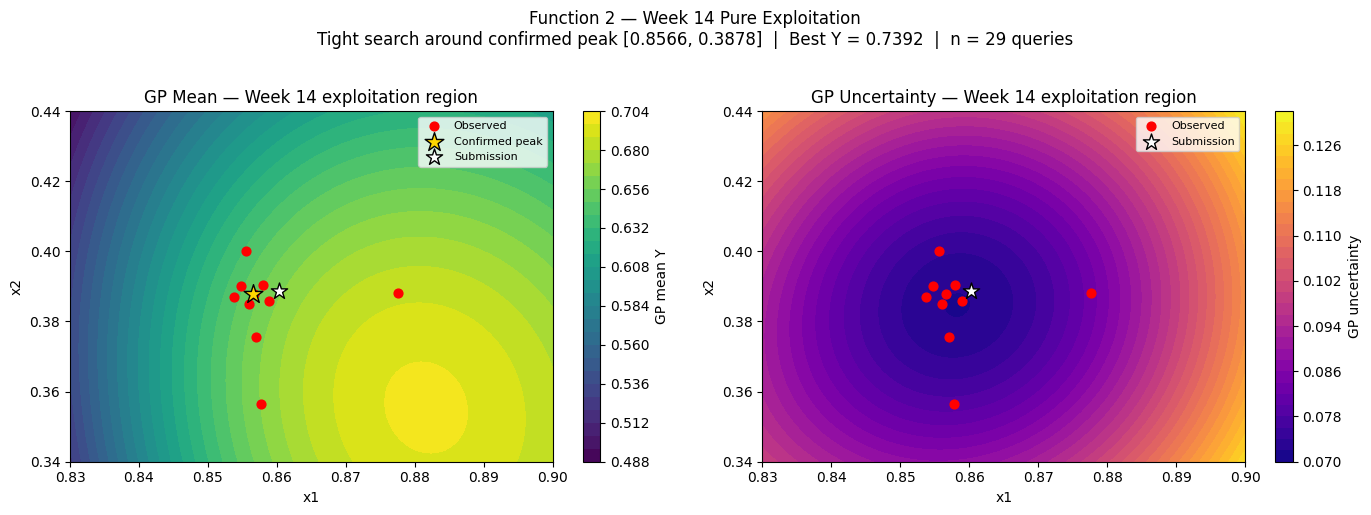


All points ranked best to worst:
  Y=0.7392 | dist=0.0000 | X=0.8566-0.3878
  Y=0.7330 | dist=0.0030 | X=0.8560-0.3849
  Y=0.7252 | dist=0.0030 | X=0.8589-0.3858
  Y=0.7031 | dist=0.0030 | X=0.8537-0.3870
  Y=0.6877 | dist=0.0313 | X=0.8577-0.3565
  Y=0.6690 | dist=0.0210 | X=0.8776-0.3882
  Y=0.6229 | dist=0.0123 | X=0.8570-0.3755
  Y=0.6174 | dist=0.0030 | X=0.8580-0.3905
  Y=0.5638 | dist=0.0030 | X=0.8547-0.3901
  Y=0.5550 | dist=0.0125 | X=0.8556-0.4002
  Y=0.4385 | dist=0.5695 | X=0.6720-0.9266
  Y=-0.0000 | dist=0.4468 | X=0.5551-0.0580
  Y=-0.0262 | dist=0.4402 | X=0.4165-0.3796
  Y=-0.0348 | dist=0.4273 | X=0.4926-0.6116
  Y=-0.0364 | dist=0.4238 | X=0.6001-0.7251
  Y=-0.0390 | dist=0.5800 | X=0.7992-0.9650
  Y=-0.0469 | dist=0.6424 | X=0.2205-0.2978
  Y=-0.0480 | dist=0.7412 | X=0.1346-0.2199
  Y=-0.0568 | dist=0.4858 | X=0.9660-0.8611
  Y=-0.0880 | dist=0.6658 | X=0.2421-0.6441
  Y=-0.0942 | dist=0.7526 | X=0.1705-0.6970
  Y=-0.1060 | dist=0.3422 | X=0.6660-0.6720
  Y=-0.11

In [16]:
# =====================================================
# FUNCTION 2 — 2D Noisy Log-Likelihood
# Week 10: complete rewrite — pure exploitation
#           All exploration abandoned — full history
#           shows every direction from [0.8566, 0.3878]
#           is worse:
#             x2 lower (0.3755, 0.3565) — worse
#             x2 higher (0.4002) — worse
#             x1 higher (0.8776) — worse
#             second cluster (0.672, 0.927) — much worse
#           Noisy function: repeated queries near peak
#           give chance of lucky positive noise draw
#           above 0.7392
# Week 11: std widened 0.003 → 0.005 to give GP more
#           candidates across confirmed region
# Week 12: LOO-based EI override threshold introduced
#           (gp_rmse * 0.5) — gives GP autonomy when
#           well calibrated
# Week 13: no structural changes — continued tight
#           exploitation around confirmed peak
# Strategy weeks 10-13: tight noise around peak,
# trust proximity over model predictions
# =====================================================
from sklearn.gaussian_process.kernels import Matern
 
# =====================================================
# GP MODEL — Matérn nu=2.5
# Smoother than nu=0.5 — appropriate for noisy
# log-likelihood landscape
# WhiteKernel models observation noise explicitly
# =====================================================
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(dim),
             length_scale_bounds=(1e-3, 1e4),
             nu=2.5)
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-8, 1e-1))
)
 
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
 
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
gp.fit(X_scaled, Y)
 
print("Fitted kernel:")
print(gp.kernel_)
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 9999 or ls <= 0.002 else ""
    print(f"  x{i+1} length scale: {ls:.4f}{flag}")
 
best_point = X[np.argmax(Y)]
 
# confirmed_peak: cross-checked against argmax(Y) each week
# Update if best_point diverges from this value
confirmed_peak = np.array([0.8566, 0.3878])
 
if not np.allclose(best_point, confirmed_peak, atol=0.01):
    print(f"\nWARNING: best_point {best_point} has diverged "
          f"from confirmed_peak {confirmed_peak} — "
          f"consider updating confirmed_peak")
 
print(f"\nBest real point:    {best_point}")
print(f"Confirmed peak:     {confirmed_peak}")
print(f"Best real Y:        {np.max(Y):.6f}")
 
# =====================================================
# LOO CROSS VALIDATION
# =====================================================
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import cdist
 
loo       = LeaveOneOut()
gp_errors = []
 
for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
 
    scaler_cv = StandardScaler()
    X_train_s = scaler_cv.fit_transform(X_train)
    X_test_s  = scaler_cv.transform(X_test)
 
    gp_cv = GaussianProcessRegressor(
        kernel=kernel, random_state=42,
        normalize_y=True, alpha=1e-6)
    gp_cv.fit(X_train_s, Y_train)
    gp_errors.append(
        (gp_cv.predict(X_test_s)[0] - Y_test[0])**2)
 
gp_rmse = np.sqrt(np.mean(gp_errors))
print(f"\nGP LOO RMSE: {gp_rmse:.6f}")
 
# =====================================================
# GENERATE CANDIDATES — pure exploitation
# Week 11: std widened 0.003 → 0.005 to give GP
#           more candidates to evaluate across the
#           confirmed region; improves EI coverage
# Weeks 12-13: no further changes to candidate
#              generation — std=0.005 retained
# =====================================================
np.random.seed(42)
n_candidates = 300000
 
noise      = np.random.normal(0, 0.005,
                               size=(n_candidates, dim))
candidates = np.clip(confirmed_peak + noise,
                     0.0, 0.999999)
 
# Hard clips — prevent drift into confirmed worse regions
# x1: don't go above 0.870 (0.8776 confirmed worse, week 9)
# x2: don't go below 0.370 (0.3565 confirmed worse, week 8)
#     don't go above 0.405 (0.4002 confirmed worse, week 9)
# No new confirmed-worse directions found in weeks 10-13
candidates[:, 0] = np.clip(candidates[:, 0],
                             0.840, 0.870)
candidates[:, 1] = np.clip(candidates[:, 1],
                             0.370, 0.405)
 
print(f"\nCandidate x1 range: "
      f"{candidates[:,0].min():.4f} — "
      f"{candidates[:,0].max():.4f}")
print(f"Candidate x2 range: "
      f"{candidates[:,1].min():.4f} — "
      f"{candidates[:,1].max():.4f}")
 
# Remove already queried points
min_dists = cdist(candidates, X).min(axis=1)
X_novel   = candidates[min_dists >= 0.003]
 
print(f"Novel candidates:   {len(X_novel)}")
 
if len(X_novel) < 500:
    print("WARNING: relaxing distance threshold")
    X_novel = candidates[min_dists >= 0.001]
 
X_novel_scaled = scaler.transform(X_novel)
 
# =====================================================
# ACQUISITION FUNCTION
# =====================================================
def expected_improvement(X_cands_scaled, gp,
                          Y_ref, xi=0.01):
    mean, std = gp.predict(X_cands_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei
 
# =====================================================
# SCORE CANDIDATES — two approaches
# EI: model-driven acquisition
# Proximity: pure geometry — most defensible given
#            noisy function and unreliable surrogates
# =====================================================
 
# EI
ei_scores   = expected_improvement(
    X_novel_scaled, gp, Y, xi=0.01)
x_submit_ei = X_novel[np.argmax(ei_scores)]
pred_ei     = gp.predict(
    scaler.transform([x_submit_ei]))[0]
dist_ei     = np.linalg.norm(
    x_submit_ei - confirmed_peak)
 
# Proximity
dists_to_peak = cdist(X_novel, [confirmed_peak])
x_submit_prox = X_novel[np.argmin(dists_to_peak)]
pred_prox     = gp.predict(
    scaler.transform([x_submit_prox]))[0]
dist_prox     = np.linalg.norm(
    x_submit_prox - confirmed_peak)
 
# =====================================================
# COMPARISON
# =====================================================
print("\n" + "="*50)
print("ACQUISITION COMPARISON — Function 2")
print("="*50)
 
for name, x_sub, pred, dist in [
    ("EI",        x_submit_ei,   pred_ei,   dist_ei),
    ("Proximity", x_submit_prox, pred_prox, dist_prox),
]:
    print(f"\n--- {name} ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  x1={x_sub[0]:.6f} | x2={x_sub[1]:.6f}")
    print(f"  GP predicted Y:     {pred:.4f}")
    print(f"  Distance from peak: {dist:.6f}")
    print(f"  x1 vs peak: {x_sub[0]-confirmed_peak[0]:+.6f}")
    print(f"  x2 vs peak: {x_sub[1]-confirmed_peak[1]:+.6f}")
 
# =====================================================
# SUBMISSION SELECTION
# Proximity default — noisy function means GP
# prediction is unreliable as absolute forecast.
# Proximity stays closest to the only confirmed
# high-value region in the entire search space.
#
# Week 12 onwards: EI override enabled — wins if GP
# predicts meaningfully higher (half a LOO RMSE unit)
# and candidate stays within confirmed region.
# Retained unchanged through week 13.
# =====================================================
x_final      = x_submit_prox
chosen_model = "Proximity"
 
ei_threshold = gp_rmse * 0.5
if pred_ei > pred_prox + ei_threshold and dist_ei <= 0.015:
    x_final      = x_submit_ei
    chosen_model = "EI (GP trusted — LOO-based threshold)"
    print(f"\nEI override: pred_ei={pred_ei:.4f} > "
          f"pred_prox={pred_prox:.4f} + "
          f"threshold={ei_threshold:.4f}")
 
submission = "-".join([f"{x:.6f}" for x in x_final])
dist_final = np.linalg.norm(x_final - confirmed_peak)
 
print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP predicted Y:     "
      f"{gp.predict(scaler.transform([x_final]))[0]:.4f}")
print(f"Best real Y:        {np.max(Y):.4f}")
print(f"Distance from peak: {dist_final:.6f}")
print(f"x1={x_final[0]:.6f} | x2={x_final[1]:.6f}")
print(f"GP LOO RMSE:        {gp_rmse:.6f}")
print(f"Dataset size:       {len(Y)}")
 
 
# =====================================================
# PLOT — zoomed view of peak region
# =====================================================
x1_range = np.linspace(0.83, 0.90, 100)
x2_range = np.linspace(0.34, 0.44, 100)
xx, yy   = np.meshgrid(x1_range, x2_range)
grid     = np.c_[xx.ravel(), yy.ravel()]
 
mean_pred, std_pred = gp.predict(
    scaler.transform(grid), return_std=True)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
cf1 = axes[0].contourf(xx, yy,
                        mean_pred.reshape(xx.shape),
                        levels=30, cmap="viridis")
plt.colorbar(cf1, ax=axes[0], label="GP mean Y")
axes[0].scatter(X[:,0], X[:,1], c="red", s=40,
                zorder=5, label="Observed")
axes[0].scatter(confirmed_peak[0], confirmed_peak[1],
                c="gold", s=200, marker="*", zorder=6,
                edgecolors="black", label="Confirmed peak")
axes[0].scatter(x_final[0], x_final[1],
                c="white", s=150, marker="*", zorder=7,
                edgecolors="black", label="Submission")
axes[0].set_xlim(0.83, 0.90)
axes[0].set_ylim(0.34, 0.44)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title(f"GP Mean — Week {current_week} exploitation region")
axes[0].legend(fontsize=8)
 
cf2 = axes[1].contourf(xx, yy,
                        std_pred.reshape(xx.shape),
                        levels=30, cmap="plasma")
plt.colorbar(cf2, ax=axes[1], label="GP uncertainty")
axes[1].scatter(X[:,0], X[:,1], c="red", s=40,
                zorder=5, label="Observed")
axes[1].scatter(x_final[0], x_final[1],
                c="white", s=150, marker="*", zorder=6,
                edgecolors="black", label="Submission")
axes[1].set_xlim(0.83, 0.90)
axes[1].set_ylim(0.34, 0.44)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title(f"GP Uncertainty — Week {current_week} exploitation region")
axes[1].legend(fontsize=8)
 
plt.suptitle(
    f"Function 2 — Week {current_week} Pure Exploitation\n"
    f"Tight search around confirmed peak "
    f"{confirmed_peak.tolist()}  |  "
    f"Best Y = {np.max(Y):.4f}  |  "
    f"n = {len(Y)} queries",
    y=1.02
)
plt.tight_layout()
plt.show()
 
# =====================================================
# FULL RESULTS TABLE
# =====================================================
sorted_idx = np.argsort(Y)[::-1]
print("\nAll points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.4f}" for v in X[i]])
    dist = np.linalg.norm(X[i] - confirmed_peak)
    print(f"  Y={Y[i]:.4f} | "
          f"dist={dist:.4f} | X={vals}")

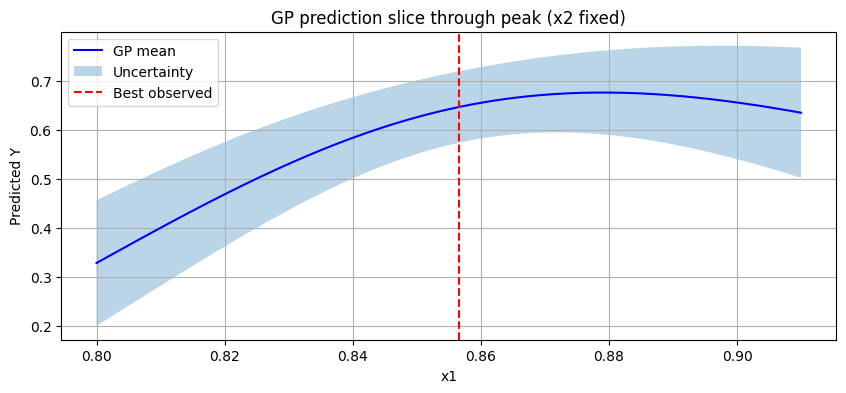

In [15]:
x1_range = np.linspace(0.80, 0.91, 200)
x2_fixed = np.full(200, best_point[1])  # hold x2 constant
slice_points = np.column_stack([x1_range, x2_fixed])
slice_scaled = scaler.transform(slice_points)
mean_slice, std_slice = gp.predict(slice_scaled, return_std=True)

plt.figure(figsize=(10, 4))
plt.plot(x1_range, mean_slice, label="GP mean", color="blue")
plt.fill_between(x1_range,
    mean_slice - std_slice,
    mean_slice + std_slice,
    alpha=0.3, label="Uncertainty")
plt.axvline(best_point[0], color="red", linestyle="--", label="Best observed")
plt.title("GP prediction slice through peak (x2 fixed)")
plt.xlabel("x1")
plt.ylabel("Predicted Y")
plt.legend()
plt.grid(True)
plt.show()